# Epidemiological Model Assignment: Parameter Exploration

**Group:** Group 02
**Members:** Claire Bams, Yustyna Babichuk, Antonia Constantin, Francisco Javier Camacho Perez de Sevilla

## Overview
This notebook investigates how the recovery rate (γ) affects epidemic outcomes
in an SIRD (Susceptible-Infected-Recovered-Dead) model, using systematic
parameter exploration and scenario comparison.

## Setup & Imports

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
import seaborn as sns

## Assignment task: Recovery rate investigation
Using the SIRD model from your practical as a starting point, you will investigate how the recovery rate affects epidemic outcomes.

## Part 1: Parameter analysis function (50 points)
Task: Create a function called analyze_recovery_rates() that systematically explores different recovery rates.

1.1 Function implementation
Create a well-documented function with the signature below

1.2 Requirements
Test recovery rates: gamma_values = [0.05, 0.1, 0.15, 0.2, 0.25]
For each γ value, calculate:
Peak number of infectious individuals
Day when peak occurs
Total deaths at end of simulation
Basic reproduction number (R₀ = β/γ)
Return results as a formatted pandas DataFrame
Generate a publication-quality plot showing all epidemic curves

1.3 Expected output format
Your function should produce:

A DataFrame with columns: ['gamma', 'R0', 'peak_infected', 'peak_day', 'total_deaths']
A matplotlib figure with properly labeled axes, legend, and title


In [71]:
def sird_model(y, t, beta, gamma, mu):

    S, I, R, D = y
    N = S + I + R + D

    dSdt = -(beta * S * I)/N
    dIdt = (beta * S * I) / N - gamma * I - mu * I
    dRdt = gamma * I
    dDdt = mu * I

    return dSdt, dIdt, dRdt, dDdt


def run_sird_simulation (beta, gamma, mu, N, I0, simulation_days):

    S0 = N - I0
    R0 = 0
    D0 = 0
    y0 = [S0, I0, R0, D0]

    t = np.linspace(0, simulation_days, simulation_days + 1)
    result = odeint(sird_model, y0, t, args=(beta, gamma, mu))

    S, I, R, D = result.T

    return t, S, I, R, D



def analyze_recovery_rates(beta, mu, N, I0, simulation_days):
    """
    Analyze epidemic outcomes for different recovery rates.

    Parameters:
    -----------
    beta : float
        Transmission rate
    mu : float
        Mortality rate
    N : int
        Total population
    I0 : int
        Initial infected individuals
    simulation_days : int
        Simulation duration in days

    Returns:
    --------
    pandas.DataFrame
        Results summary for each recovery rate
    """
    # Your implementation here

    #Test recovery rates ( for 1.2)
    gamma_values = [0.05, 0.1, 0.15, 0.2, 0.25]
    records = []

    fig, ax = plt.subplots(figsize=(10, 6))

    for gamma in gamma_values:
        t, S, I, R, D = run_sird_simulation(beta, gamma, mu, N, I0, simulation_days)


        #Peak number of infectious individuals
        peak_infected = I.max()
        #Day when peak occurs
        peak_day = t[I.argmax()]
        #Epidemic duration: first day after the peak when I < 1
        peak_index = I.argmax()
        after_peak = np.where(I[peak_index:] < 1)[0]

        if len(after_peak) > 0:
            epidemic_duration = t[peak_index + after_peak[0]]
        else:
            epidemic_duration = simulation_days
        #Total deaths at end of simulation
        total_deaths = D[-1]
        #Basic reproduction number (R₀ = β/γ)
        R0_val = beta / gamma

        #for 1.3
        records.append({
            'gamma': gamma,
            'R0': R0_val,
            'peak_infected': peak_infected,
            'peak_day': peak_day,
            'total_deaths': total_deaths,
            'epidemic_duration': epidemic_duration
        })

        ax.plot(t, I, label=f'γ={gamma} (R0={R0_val:.2f})')

    ax.set_xlabel('Day')
    ax.set_ylabel('Infected individuals')
    ax.set_title('Epidemic curves for varying recovery rates')
    ax.legend()
    sns.despine()
    plt.show()
    #Generate a publication-quality plot showing all epidemic curve

    #Return results as a formatted pandas DataFrame
    df = pd.DataFrame(records)
    return df



In [72]:

#testing out sird_model and run_sird_simulation
t_test, S_test, I_test, R_test, D_test = run_sird_simulation(beta=0.3, gamma=0.1, mu=0.01, N=1000, I0=5, simulation_days=150)
print(I_test.max(), D_test[-1])

267.25764233110704 83.52454383127375


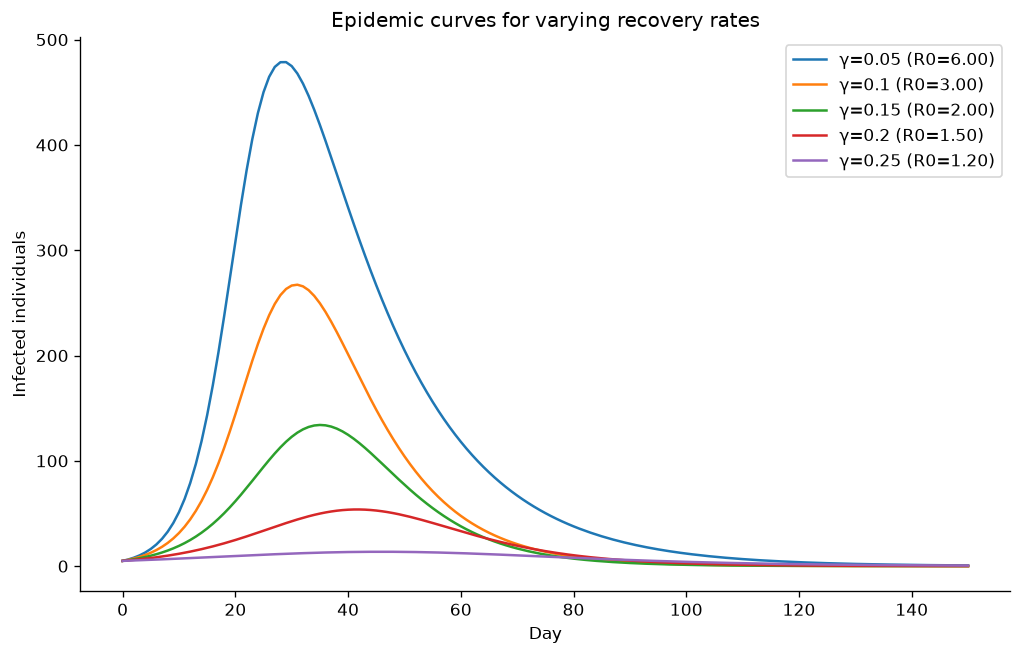

,gamma,R0,peak_infected,peak_day,total_deaths,epidemic_duration
0,0.05,6.0,478.629011,29.0,165.395739,143.0
1,0.10,3.0,267.257642,31.0,83.524544,106.0
2,0.15,2.0,134.079124,35.0,47.576918,103.0
3,0.20,1.5,53.821447,42.0,25.698484,114.0
4,0.25,1.2,13.656717,46.0,10.576698,136.0


In [73]:
#testing analyze_recovery_rates
df_test = analyze_recovery_rates(beta=0.3, mu=0.01, N=1000, I0=5, simulation_days=150)
df_test

## Part 2: Scenario Comparison (30 points)

**2.1 Scenario analysis**
Use your function to compare two scenarios:
- **Scenario A - "High Transmission":** beta=0.4, mu=0.02, N=1000, I0=5, simulation_days=200
- **Scenario B - "Low Transmission":** beta=0.2, mu=0.005, N=1000, I0=5, simulation_days=200

**2.2 Deliverables**
- Run both scenarios using your function
- Display both result DataFrames
- Create a comparative visualization (side-by-side plots or combined plot)
- Write a markdown cell analyzing which scenario is worse for public health and why

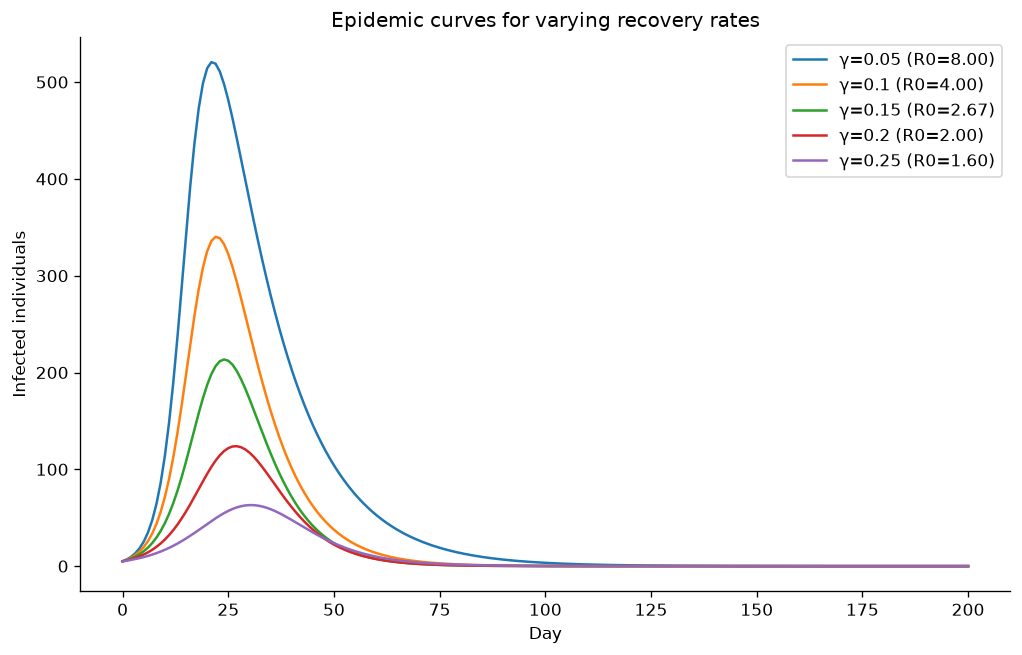

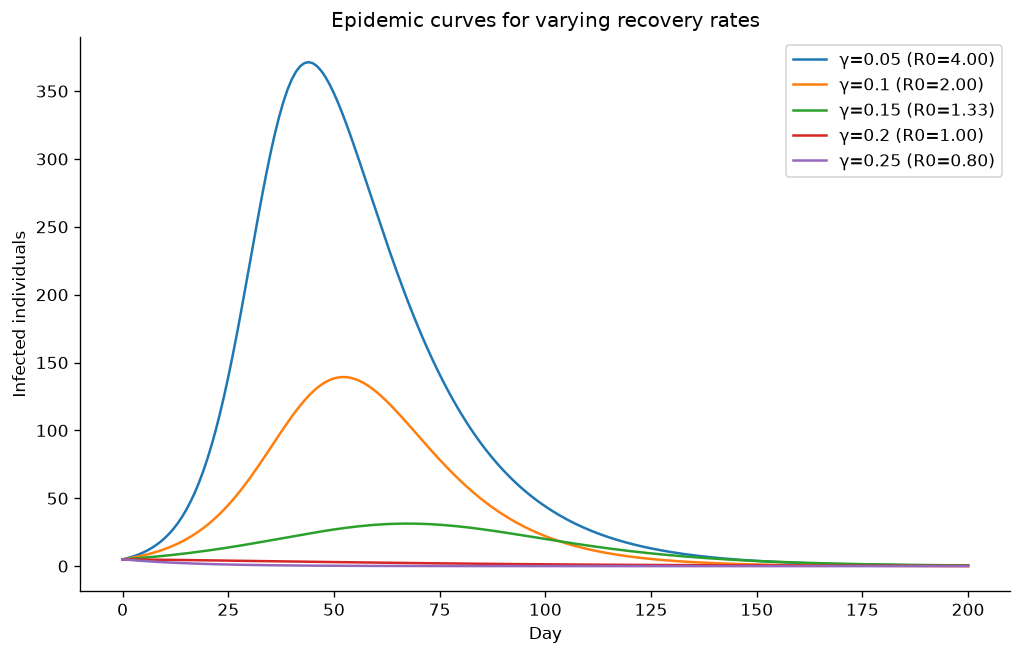

In [74]:
# Scenario A - High Transmission: beta=0.4, mu=0.02, N=1000, I0=5, simulation_days=200
df_A = analyze_recovery_rates(beta=0.4, mu=0.02, N=1000, I0=5, simulation_days=200)

# Scenario B - Low Transmission: beta=0.2, mu=0.005, N=1000, I0=5, simulation_days=200
df_B = analyze_recovery_rates(beta=0.2, mu=0.005, N=1000, I0=5, simulation_days=200)

### Results tables

In [75]:
# Display df_A and df_B
print("Scenario A Results (High Transmission)")
display(df_A)
print("\nScenario B Results (Low Transmission)")
display(df_B)




Scenario A Results (High Transmission)


,gamma,R0,peak_infected,peak_day,total_deaths,epidemic_duration
0,0.05,8.000000,520.582635,21.0,284.757434,118.0
1,0.10,4.000000,340.140583,22.0,159.892366,86.0
2,0.15,2.666667,213.465894,24.0,102.610885,77.0
3,0.20,2.000000,123.893909,27.0,67.423926,78.0
4,0.25,1.600000,63.051893,30.0,42.694003,84.0



Scenario B Results (Low Transmission)


,gamma,R0,peak_infected,peak_day,total_deaths,epidemic_duration
0,0.05,4.000000,371.356334,44.0,88.225824,178.0
1,0.10,2.000000,139.333450,52.0,36.700237,154.0
2,0.15,1.333333,31.340756,67.0,13.642779,185.0
3,0.20,1.000000,5.000000,0.0,1.832013,116.0
4,0.25,0.800000,5.000000,0.0,0.433167,28.0


### Comparative visualization

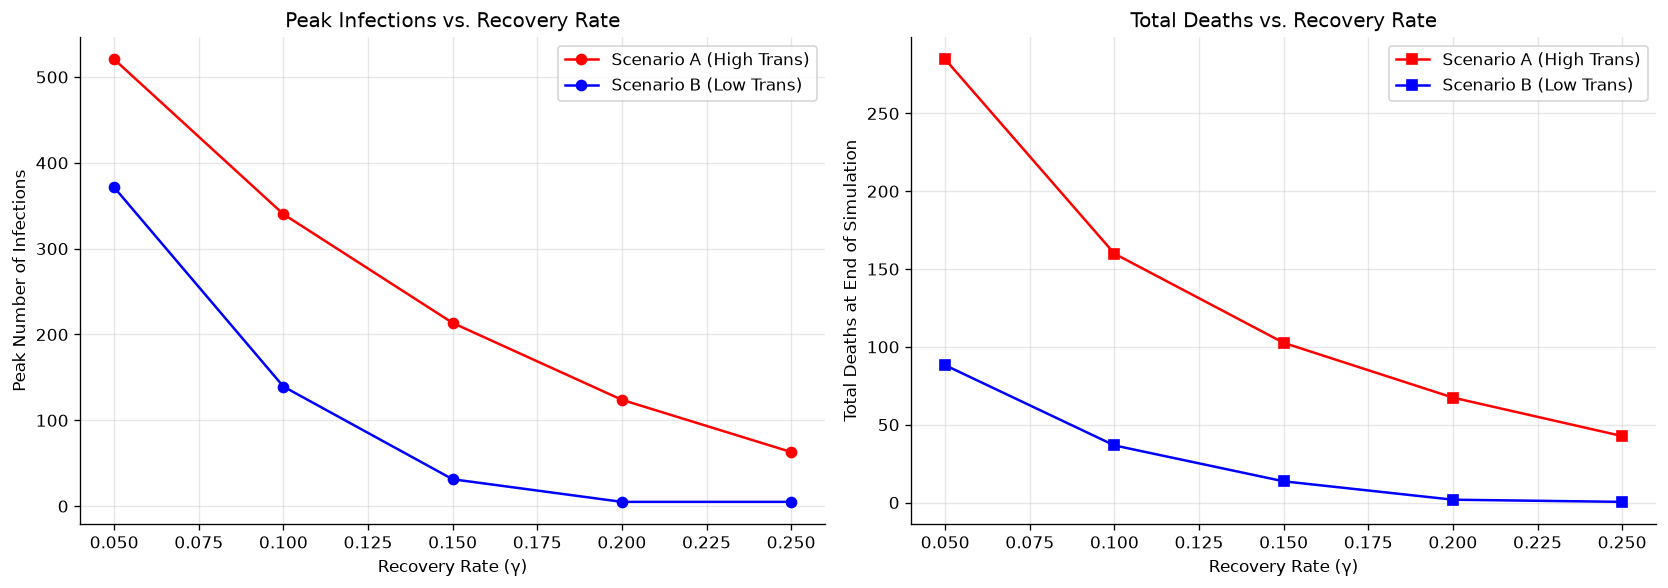

In [76]:
# Comparative visualization of Scenario A vs Scenario B
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#Peak Infected Comparison
ax1.plot(df_A['gamma'], df_A['peak_infected'], 'ro-', label='Scenario A (High Trans)')
ax1.plot(df_B['gamma'], df_B['peak_infected'], 'bo-', label='Scenario B (Low Trans)')
ax1.set_xlabel('Recovery Rate (γ)')
ax1.set_ylabel('Peak Number of Infections')
ax1.set_title('Peak Infections vs. Recovery Rate')
ax1.legend()
ax1.grid(True, alpha=0.3)

#Total Deaths Comparison
ax2.plot(df_A['gamma'], df_A['total_deaths'], 'rs-', label='Scenario A (High Trans)')
ax2.plot(df_B['gamma'], df_B['total_deaths'], 'bs-', label='Scenario B (Low Trans)')
ax2.set_xlabel('Recovery Rate (γ)')
ax2.set_ylabel('Total Deaths at End of Simulation')
ax2.set_title('Total Deaths vs. Recovery Rate')
ax2.legend()
ax2.grid(True, alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()





### Which scenario is worse for public health, and why?

Scenario A is significantly worse in all metrics due to its higher transmission (beta=0.4) and mortality (mu=0.02) rates.
Scenario A reaches a peak of 521 infections, which creates a much higher burden on healthcare, compared to only 371 in Scenario B.
Also, Scenario A results in 285 total deaths, compared to only 88 in B.
Moreover, at the highest tested recovery rate (gamma=0.25), Scenario A's R0 is 1.6, meaning the epidemic can still grow, while Scenario B's R0 goes down to 0.8, meaning infections are expected to decline.

## Part 3: Policy Recommendations (20 points)

Create markdown cells with analysis addressing 3.1–3.3 below.

### 3.1 Parameter impact analysis

- How does increasing recovery rate affect peak infections, total deaths,
  and epidemic duration?
- Use specific numbers from your results to support your conclusions.

ANSWER:

Increasing the recovery rate improves the epidemic outcomes in both scenarios. In Scenario A, when gamma increases from 0.05 to 0.25, the peak number of infected people decreases from about 521 to 63, while total deaths decrease from about 285 to 43. The epidemic duration also becomes shorter overall, from 118 days at gamma = 0.05 to around 77–84 days for gamma values between 0.15 and 0.25. The same pattern can also be seen in Scenario B. The peak decreases from about 371 infected people at gamma = 0.05 to only 5 at gamma = 0.25, and total deaths decrease from about 88 to less than 1. The epidemic duration changes from 178 days to 28 days. Overall, a higher recovery rate means that infected people leave the infected compartment faster, which results in lower infection peaks and fewer deaths. The epidemic also generally becomes shorter, although the duration does not decrease perfectly with every increase in gamma.

### 3.2 Intervention analysis

- If an intervention could increase recovery rate by 50%, what would be the
  expected impact on total deaths?
- Use Scenario A as your baseline and show calculations.

In [77]:
# Calculation: expected impact on total deaths if recovery rate increased by 50%
# Use Scenario A as baseline

baseline_gamma = 0.10
increased_gamma = baseline_gamma * 1.5

# Total deaths taken from the Scenario A results above
baseline_deaths = 159.89
increased_gamma_deaths = 102.61

deaths_reduced = baseline_deaths - increased_gamma_deaths
percentage_reduction = (deaths_reduced / baseline_deaths) * 100

print("Recovery rate after 50% increase:", increased_gamma)
print("Deaths reduced:", round(deaths_reduced, 2))
print("Percentage reduction:", round(percentage_reduction, 2), "%")

Recovery rate after 50% increase: 0.15000000000000002
Deaths reduced: 57.28
Percentage reduction: 35.82 %


Using gamma = 0.10 as the baseline recovery rate for Scenario A, a 50% increase gives a new recovery rate of gamma = 0.15. At gamma = 0.10, the model results in about 160 total deaths, while at gamma = 0.15 this decreases to about 103 deaths. This means that increasing the recovery rate by 50% reduces the total number of deaths by about 57, which is approximately a 35.8% reduction.

### 3.3 Real-world application

- Name one real medical intervention that could increase recovery rates.
- Explain the mechanism and estimate realistic effectiveness.

One real medical intervention that could increase the recovery rate is antiviral medication. Antiviral drugs can help the body fight a viral infection by reducing how quickly the virus reproduces, which can shorten the time a person stays infected and therefore increase the recovery rate. The actual effectiveness would depend on the disease and the specific treatment, so it is not possible to give one realistic percentage for all cases. In the model, a successful antiviral treatment would be represented by a higher gamma, meaning that infected people move into the recovered group faster. This would be expected to reduce the number of infected people and also lower the number of deaths.

## Conclusions

[Your summary here]